# Criticality monitor on a closing spectral gap

`monitor_critical_transition` scores a sequence of spectra. On
$K_t=\mathrm{diag}(1, 1+\delta_t)$ with $\delta_t$ closing from 1
to 0, the windowed closure rate is positive and larger than a
constant-gap control.

**Honesty.** The score is a heuristic. It is **not** a certificate
and not Ghosh (2025) neural Koopman forecasting for infrastructure
transitions. This notebook does **not** download METR-LA.


## Setup

Package version, eleven diagonal spectra, and window 5.


In [1]:
from __future__ import annotations

import os

import matplotlib

if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import torch

import koopman_graph
from koopman_graph.analysis import monitor_critical_transition
from koopman_graph.spectrum_types import compute_spectrum

print("koopman_graph", koopman_graph.__version__)

N_TIMES = 11
WINDOW = 5
GAP0 = 1.0


def diagonal_spectrum(primary: float, secondary: float):
    matrix = torch.diag(torch.tensor([primary, secondary], dtype=torch.float64))
    return compute_spectrum(matrix, time_step=1.0)


def closing_spectra():
    spectra = []
    for step in range(N_TIMES):
        gap = GAP0 * (1.0 - step / (N_TIMES - 1))
        spectra.append(diagonal_spectrum(1.0, 1.0 + gap))
    return spectra


def stable_spectra():
    return [diagonal_spectrum(1.0, 1.0 + GAP0) for _ in range(N_TIMES)]


koopman_graph 0.15.0


## Motivation and background

The closest-eigenvalue gap on a stored spectrum is
$\gamma_t=\min_{i\neq j}\lvert\lambda_i(t)-\lambda_j(t)\rvert$.
On this $2\times 2$ diagonal toy, $\gamma_t=\delta_t$. Without
the helper, a caller would difference those gaps by hand and
could treat a shrinking gap as a Ghosh-style early-warning
score. The helper only records windowed shrinkage from spectra
the caller already computed.

Ghosh (2025) is related literature for infrastructure
forecasting and the honesty ceiling for this helper, not an
implemented method
([doi:10.1016/j.iswa.2025.200575](https://doi.org/10.1016/j.iswa.2025.200575)).


## Minimal example

Linearly closing $\delta_t=1-t/10$ versus a constant gap.


In [2]:
closing = monitor_critical_transition(closing_spectra(), window=WINDOW)
control = monitor_critical_transition(stable_spectra(), window=WINDOW)
print("closing max score", closing.max_gap_closure_rate)
print("control max score", control.max_gap_closure_rate)
assert closing.max_gap_closure_rate > control.max_gap_closure_rate
assert abs(closing.max_gap_closure_rate - 0.1) < 1e-12
assert abs(control.max_gap_closure_rate) < 1e-12
print("score rose versus the constant-gap control")


closing max score 0.10000000000000003
control max score 0.0
score rose versus the constant-gap control


## Progressive deep dive

Window-5 closure on unit sample times is
$(\gamma_{t-4}-\gamma_t)/4=0.1$ at every valid $t$
(window end $t=4,\ldots,10$). All `near_defective` flags are
false: this diagonal eigenbasis remains usable even when
$\gamma_t=0$ at the last spectrum. Coalescence is not
near-defectivity.


In [3]:
print("gaps", closing.spectral_gap.tolist())
print("rates", closing.gap_closure_rate.tolist())
print("near_defective", closing.near_defective.tolist())
assert not bool(closing.near_defective.any().item())


gaps [1.0, 0.8999999999999999, 0.8, 0.7, 0.6000000000000001, 0.5, 0.3999999999999999, 0.30000000000000004, 0.19999999999999996, 0.10000000000000009, 0.0]
rates [0.09999999999999998, 0.09999999999999998, 0.10000000000000003, 0.09999999999999998, 0.10000000000000003, 0.09999999999999998, 0.09999999999999998]
near_defective [False, False, False, False, False, False, False, False, False, False, False]


Doubling the sample times ($\tau_t=2t$) halves the rate: the
same $\Delta\gamma$ is divided by a longer $\Delta\tau$.


In [4]:
times = [2.0 * step for step in range(N_TIMES)]
scaled = monitor_critical_transition(
    closing_spectra(), window=WINDOW, sample_times=times
)
print("unit-time max score", closing.max_gap_closure_rate)
print("doubled-time max score", scaled.max_gap_closure_rate)
assert abs(scaled.max_gap_closure_rate - 0.05) < 1e-12
print("doubling tau halved the closure rate")


unit-time max score 0.10000000000000003
doubled-time max score 0.05000000000000002
doubling tau halved the closure rate


## Results

The figure plots the gap $\gamma_t$, not the scalar score
`max_gap_closure_rate`. The blue series falls linearly from
$1$ to $0$ over spectrum indices $0$ through $10$. The orange
control stays at $1$. That constructed shrinkage is why the
window-5 score on unit sample times is $0.1$ eigenvalue units
per step versus $0$.


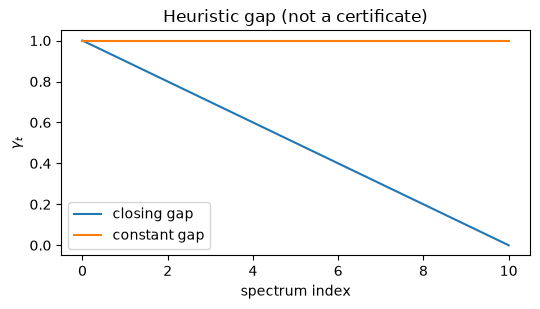

In [5]:
fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.plot(closing.spectral_gap.numpy(), label="closing gap")
ax.plot(control.spectral_gap.numpy(), label="constant gap")
ax.set_xlabel("spectrum index")
ax.set_ylabel(r"$\gamma_t$")
ax.set_title("Heuristic gap (not a certificate)")
ax.legend()
fig.tight_layout()
plt.show()


## Interpretation / discussion

The score rises because $\gamma_t$ shrank, by construction.
That is the teaching check against the constant-gap control.
Doubling $\tau$ halves the rate without changing the gap
trajectory. The last spectrum has $\gamma_t=0$ and still does
not flag near-defectivity.

The helper is not an early-warning product and not a Ghosh
certificate. Callers still have to supply spectra; the monitor
does not fit a model or infer edges.


## Takeaways

- When to use: after you already have a `KoopmanSpectrum`
  sequence and want a sliding-window record of whether the
  closest-eigenvalue gap shrank.
- When not to use: not a topology-criticality certificate,
  not a Ghosh (2025) early-warning product, not a stability
  certificate, and not a forecast-horizon collapse test.
  This notebook is a diagonal toy and does **not** download
  METR-LA.
- Gotchas: $2\le w\le T$; default $\tau$ is unit-spaced
  (doubling $\tau$ halves the rate); pairwise min, not
  magnitude-adjacent neighbors; coalescence is not
  near-defectivity on a well-conditioned eigenbasis.
  Positive rate means the gap shrank.


## Further reading

- Sphinx: [Spectral-gap criticality monitor](https://koopmangraph.readthedocs.io/en/latest/criticality.html),
  [Spectral diagnostics](https://koopmangraph.readthedocs.io/en/latest/spectral_diagnostics.html),
  [API reference](https://koopmangraph.readthedocs.io/en/latest/api.html)
  (`monitor_critical_transition`)
- Ghosh (2025), *Intelligent Systems with Applications*
  ([doi:10.1016/j.iswa.2025.200575](https://doi.org/10.1016/j.iswa.2025.200575))
- Example [51_spectral_diagnostics.ipynb](51_spectral_diagnostics.ipynb)
